In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from matplotlib.colors import LogNorm
import matplotlib
matplotlib.use('TkAgg')
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Helvetica']
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("table_group_params.csv")

In [3]:
rproj_fit_mult=df.rproj_fit_mult.to_numpy()
vproj_fit_mult=df.vproj_fit_mult.to_numpy()
vproj_fit_offset=df.vproj_fit_offset.to_numpy()
gdrproj_fit_mult=df.gd_rproj_fit_mult.to_numpy()
gdvproj_fit_mult=df.gd_vproj_fit_mult.to_numpy()
gdvproj_fit_offset=df.gd_vproj_fit_offset.to_numpy()
labels=["({a:d},{b:d},{c:d},{d:d},{e:d},{f:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii], d=gdrproj_fit_mult[ii], e=gdvproj_fit_mult[ii], f=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
labels_for_giant_params=["({a:d}, {b:d}, {c:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'labels_giant_params']=labels_for_giant_params

In [4]:
giantresults = df.groupby('labels_giant_params').median()
giantresults=giantresults[(giantresults.rproj_fit_mult>1)&(giantresults.vproj_fit_mult>1)]

In [5]:
giantresults

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(2, 2, 100)",2.0,2.0,100.0,3.5,3.5,150.0,0.163,0.221737,0.200000,0.992472,...,0.887022,0.989843,0.948357,0.962614,0.945694,0.921027,0.953707,0.164000,7863.5,328.0
"(2, 2, 200)",2.0,2.0,200.0,3.5,3.5,150.0,0.161,0.224871,0.204000,0.992058,...,0.893485,0.990130,0.950831,0.963146,0.950705,0.922300,0.957619,0.167000,7754.0,324.0
"(2, 2, 300)",2.0,2.0,300.0,3.5,3.5,150.0,0.161,0.237029,0.197000,0.991659,...,0.897342,0.990229,0.951521,0.962091,0.952514,0.921170,0.958062,0.167177,7699.0,320.0
"(2, 3, 100)",2.0,3.0,100.0,3.5,3.5,150.0,0.162,0.237029,0.204000,0.992225,...,0.893273,0.990296,0.949831,0.962509,0.951539,0.922210,0.956982,0.166000,7769.0,327.0
"(2, 3, 200)",2.0,3.0,200.0,3.5,3.5,150.0,0.161,0.240184,0.197000,0.991825,...,0.898353,0.990299,0.951497,0.962860,0.953533,0.921870,0.958491,0.167000,7696.0,323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",6.0,5.0,200.0,3.5,3.5,150.0,0.201,0.870974,0.476305,0.965008,...,0.971669,0.977810,0.985339,0.914003,0.986575,0.754550,0.988095,0.254000,5675.5,408.0
"(6, 5, 300)",6.0,5.0,300.0,3.5,3.5,150.0,0.202,0.909230,0.494000,0.963563,...,0.972733,0.976927,0.986082,0.912006,0.986765,0.759259,0.989194,0.256123,5625.0,411.0
"(6, 6, 100)",6.0,6.0,100.0,3.5,3.5,150.0,0.200,0.870211,0.475000,0.966623,...,0.969554,0.978280,0.984172,0.910142,0.984177,0.751938,0.986442,0.253000,5703.0,407.0


In [6]:
giantmaxs=df.groupby('labels_giant_params').max()
giantmins = df.groupby('labels_giant_params').min()

In [7]:
giantrangedf = giantmaxs-giantmins

In [8]:
giantrangedf

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups
labels_giant_params,,,,,,,,,,,,,,,,,,,,,
"(1, 1, 100)",0,0,0,5,5,300,0.006000,0.000000,0.000000,0.002982,...,0.043102,0.006507,0.024159,0.057088,0.072034,0.103477,0.053444,0.019636,494,468
"(1, 1, 200)",0,0,0,5,5,300,0.005000,0.000000,0.000000,0.002779,...,0.042118,0.006014,0.023773,0.053746,0.057565,0.097983,0.045454,0.030000,472,450
"(1, 1, 300)",0,0,0,5,5,300,0.005000,0.000000,0.000000,0.002662,...,0.040569,0.005692,0.023100,0.051651,0.049279,0.092309,0.040234,0.058684,452,432
"(1, 2, 100)",0,0,0,5,5,300,0.005000,0.000000,0.000000,0.002901,...,0.042467,0.006390,0.023961,0.055810,0.060477,0.099988,0.048656,0.018363,480,456
"(1, 2, 200)",0,0,0,5,5,300,0.005000,0.000000,0.000000,0.002819,...,0.042298,0.006215,0.024069,0.054539,0.049899,0.098525,0.044701,0.023338,472,449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 200)",0,0,0,5,5,300,0.015000,0.000929,0.000844,0.012520,...,0.050128,0.029227,0.026049,0.113856,0.029117,0.137420,0.022927,0.040000,476,428
"(6, 5, 300)",0,0,0,5,5,300,0.015992,0.030477,0.000000,0.013278,...,0.049623,0.031323,0.025663,0.123726,0.025825,0.129328,0.021809,0.041710,481,430
"(6, 6, 100)",0,0,0,5,5,300,0.014000,0.002340,0.000000,0.012312,...,0.051185,0.029186,0.026741,0.116381,0.030651,0.156927,0.023761,0.041069,483,440


# Lollipop chart for selecting dwarf-association parameters

In [9]:
pg=giantresults.P_G.to_numpy()
cg=giantresults.C_G.to_numpy()
ph=giantresults.P_H.to_numpy()
ch=giantresults.C_H.to_numpy()
mu_phys=giantresults.mu_HME.to_numpy()
mu=giantresults.mu_HME.to_numpy()#/np.median(giantresults.mu_HME.to_numpy())
fn=interp1d([np.max(mu),np.min(mu)],[0.7,1])
mu=fn(mu)
mu_dyn=giantresults.mu_HME_dyn.to_numpy()
mu_dyn_rank = interp1d([np.max(mu_dyn),np.min(mu_dyn)],[0.7,1])(mu_dyn)
#mu=1-rankdata(mu,'max')/len(x)
pgtimescg=pg*cg
phtimesch=ph*ch
pgrange=giantrangedf.P_G.to_numpy()
cgrange=giantrangedf.C_G.to_numpy()
phrange=giantrangedf.P_H.to_numpy()
chrange=giantrangedf.C_H.to_numpy()
mu_physrange=giantrangedf.mu_HME.to_numpy()

order=np.argsort(pgtimescg)
pg=pg[order]
cg=cg[order]
ch=ch[order]
ph=ph[order]
mu=mu[order]
mu_dyn=mu_dyn[order]
mu_dyn_rank=mu_dyn_rank[order]
mu_phys=mu_phys[order]
phtimesch=phtimesch[order]
pgtimescg=pgtimescg[order]
pgrange=pgrange[order]
cgrange=cgrange[order]
phrange=phrange[order]
chrange=chrange[order]
newlabels=np.array(giantresults.index.to_numpy())[order]

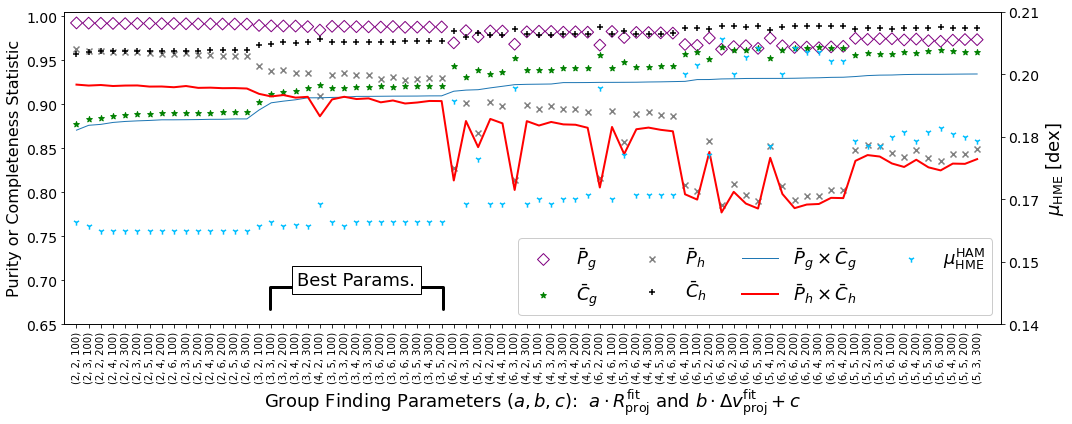

In [23]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,6))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label=r'$\bar{P}_{g}$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label=r'$\bar{C}_{g}$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label=r'$\bar{P}_{h}$')
ax.scatter(myrange-1,ch,color='k',marker='+', label=r'$\bar{C}_{h}$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=1,label=r'$\bar{P}_g \times \bar{C}_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$\bar{P}_h \times \bar{C}_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=10)
ax.set_ylim(0.65,1.005)
ytvals = np.arange(0.65,1.05,0.05)
ax.set_yticks(ytvals, ["{:0.2f}".format(x) for x in ytvals], fontsize=14)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=16)
ax1=ax.twinx()
ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=18)

hme_ylim = [0.14,0.21]
step=(hme_ylim[1]-hme_ylim[0])/5.
ax1.set_ylim(*hme_ylim)
hme_ytvals = np.arange(hme_ylim[0],hme_ylim[1]+step,step)
ax1.set_yticks(hme_ytvals, ["{:0.2f}".format(x) for x in hme_ytvals], fontsize=14)

ax.legend(loc='lower right', framealpha=1, fontsize=18, ncol=4)
ax.annotate(r'Best Params.', xy=(23,0.69), 
            fontsize=18, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white'),
            arrowprops=dict(arrowstyle='-[, widthB=4.8, lengthB=1.2', lw=3.0))
#ax.annotate(r"Parameters $(a,b,c)$:  $a\cdot R_{\rm proj}^{\rm fit}$ and $b \cdot \Delta v_{\rm proj}^{\rm fit}+c$",\
#            xy=(1,0.67),fontsize=18)
ax.set_xlabel(r"Group Finding Parameters $(a,b,c)$:  $a\cdot R_{\rm proj}^{\rm fit}$ and $b \cdot \Delta v_{\rm proj}^{\rm fit}+c$",\
              fontsize=18)
plt.tight_layout()
plt.savefig("../figures/optimal_params_giants.pdf",dpi=300)
plt.show()

Dynamical masses?

In [25]:
diff = np.abs(df.mu_HME_dyn - df.mu_HME_HAMngt7)
df.loc[:,'diff']=diff

In [26]:
df.sort_values(by='diff')

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params,diff
1005,1,3,100,6,6,100,0.164,0.194304,0.194206,0.991998,...,0.946018,0.945955,0.910824,0.897663,0.929094,0.159000,8150,515,"(1, 3, 100)",0.000099
912,1,3,100,3,1,0,0.169,0.194304,0.194206,0.994526,...,0.927642,0.975309,0.901839,0.945523,0.914025,0.170000,8524,162,"(1, 3, 100)",0.000099
911,1,3,100,2,6,300,0.167,0.194304,0.194206,0.994598,...,0.930662,0.985294,0.926759,0.965078,0.943045,0.150363,8482,204,"(1, 3, 100)",0.000099
910,1,3,100,2,6,200,0.167,0.194304,0.194206,0.994598,...,0.930662,0.985294,0.926759,0.965078,0.943045,0.150363,8482,204,"(1, 3, 100)",0.000099
909,1,3,100,2,6,100,0.167,0.194304,0.194206,0.994598,...,0.930662,0.985294,0.926759,0.965078,0.943045,0.150363,8482,204,"(1, 3, 100)",0.000099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15468,6,6,300,3,4,0,0.204,0.954497,0.501000,0.963198,...,0.986518,0.930888,0.988038,0.799170,0.989464,0.253000,5577,418,"(6, 6, 300)",0.453497
15461,6,6,300,3,2,100,0.204,0.954497,0.501000,0.963175,...,0.986483,0.930722,0.988010,0.798784,0.989443,0.251859,5576,417,"(6, 6, 300)",0.453497
15500,6,6,300,4,6,0,0.206,0.954497,0.501000,0.960042,...,0.988701,0.896984,0.987945,0.761005,0.988951,0.262382,5504,477,"(6, 6, 300)",0.453497
15424,6,6,300,1,5,0,0.195,0.954497,0.501000,0.966560,...,0.970315,0.944181,0.980159,0.758123,0.984958,0.242715,5804,210,"(6, 6, 300)",0.453497


In [29]:
df[df.labels_giant_params=='(3, 4, 200)']

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,mu_HME_HAMngt7,P_G,...,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,n_dwgroups,n_Ngt1dwgroups,labels_giant_params,diff
6624,3,4,200,1,1,0,0.161,0.341616,0.222,0.989607,...,0.945773,0.939815,0.938034,0.821053,0.949123,0.189490,7390,78,"(3, 4, 200)",0.119616
6625,3,4,200,1,1,100,0.161,0.342015,0.222,0.989530,...,0.949593,0.962607,0.961538,0.878378,0.966216,0.181257,7336,130,"(3, 4, 200)",0.120015
6626,3,4,200,1,1,200,0.161,0.341616,0.222,0.989549,...,0.949593,0.963889,0.961538,0.884354,0.965986,0.181245,7337,130,"(3, 4, 200)",0.119616
6627,3,4,200,1,1,300,0.161,0.341609,0.222,0.989551,...,0.949527,0.963889,0.961538,0.884354,0.965986,0.181245,7339,130,"(3, 4, 200)",0.119609
6628,3,4,200,1,2,0,0.161,0.341609,0.222,0.989566,...,0.948575,0.959877,0.957265,0.873134,0.962687,0.170000,7352,117,"(3, 4, 200)",0.119609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6763,3,4,200,6,5,300,0.163,0.342015,0.222,0.985202,...,0.972245,0.921605,0.972498,0.850187,0.974121,0.186090,6931,504,"(3, 4, 200)",0.120015
6764,3,4,200,6,6,0,0.163,0.341609,0.222,0.985225,...,0.972249,0.922090,0.972552,0.851865,0.974121,0.187000,6933,505,"(3, 4, 200)",0.119609
6765,3,4,200,6,6,100,0.163,0.341613,0.222,0.985224,...,0.972176,0.921936,0.972498,0.851616,0.974078,0.186078,6933,504,"(3, 4, 200)",0.119613
6766,3,4,200,6,6,200,0.163,0.341609,0.222,0.985225,...,0.972249,0.922090,0.972552,0.851865,0.974121,0.187000,6933,505,"(3, 4, 200)",0.119609


In [ ]:
len(ph)

In [ ]:
# myrange=np.arange(1,len(pg)+1)
# fig,ax=plt.subplots(figsize=(15,4))
# ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
# ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
# ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
# ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
# ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
# ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
# ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
# ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
# ax.set_ylim(0.7,1.0)
# ax.set_xlim(-1,max(myrange)+1)
# ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
# ax1=ax.twinx()
# #ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
# ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
# #ax1.set_ylim(0.15,0.18)

# ax.legend(loc='lower left', framealpha=1, fontsize=12, ncol=4)
# plt.show()

In [ ]:
# myrange=np.arange(1,len(pg)+1)
# fig,ax=plt.subplots(figsize=(15,4))
# ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
# ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
# ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
# ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
# ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
# ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
# ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
# ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
# ax.set_ylim(0.7,1.0)
# ax.set_xlim(-1,max(myrange)+1)
# ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
# #ax1=ax.twinx()
# ax.scatter(myrange-1,mu,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# ax.scatter(myrange-1,mu_dyn_rank,marker='2',color='olive',s=60, label=r'$\mu_{\rm HME}^{\rm dyn}$')
# #ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
# #ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
# ax.set_ylim(0.68,1.02)
# ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
# plt.show()